In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("ML environment is ready!")

ML environment is ready!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/raw/inventory_data.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
print(df.info())


Dataset shape: (1460, 13)

Columns:
['date', 'ingredient', 'students_present', 'meals_served', 'opening_stock', 'received_quantity', 'closing_stock', 'consumption', 'day_of_week', 'month', 'holiday', 'current_stock', 'minimum_stock']

Missing values:
date                 0
ingredient           0
students_present     0
meals_served         0
opening_stock        0
received_quantity    0
closing_stock        0
consumption          0
day_of_week          0
month                0
holiday              0
current_stock        0
minimum_stock        0
dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               1460 non-null   datetime64[us]
 1   ingredient         1460 non-null   str           
 2   students_present   1460 non-null   int64         
 3   meals_served       1460 non-null   int6

ingredient
Rice     44269.52
Wheat    25612.55
Dal      13788.85
Oil       5369.64
Name: consumption, dtype: float64


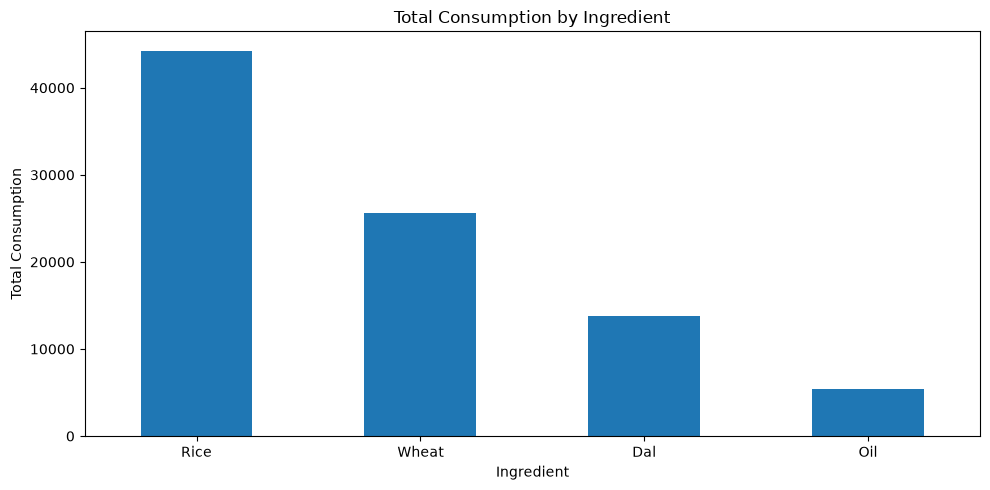

In [3]:
# Total consumption by ingredient

consumption_by_ingredient = (
    df.groupby("ingredient")["consumption"]
    .sum()
    .sort_values(ascending=False)
)

print(consumption_by_ingredient)

plt.figure(figsize=(10, 5))
consumption_by_ingredient.plot(kind="bar")

plt.title("Total Consumption by Ingredient")
plt.xlabel("Ingredient")
plt.ylabel("Total Consumption")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


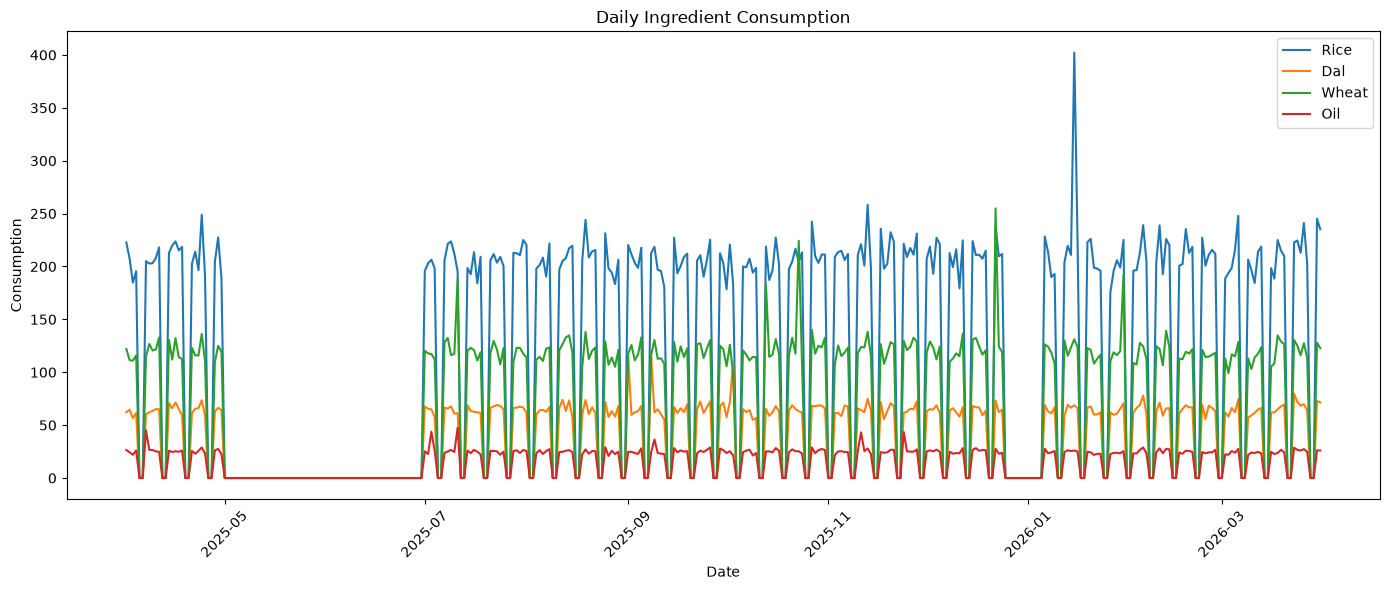

In [4]:
# Daily consumption trend for each ingredient

daily_consumption = (
    df.groupby(["date", "ingredient"])["consumption"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

for ingredient in df["ingredient"].unique():
    ingredient_data = daily_consumption[
        daily_consumption["ingredient"] == ingredient
    ]

    plt.plot(
        ingredient_data["date"],
        ingredient_data["consumption"],
        label=ingredient
    )

plt.title("Daily Ingredient Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

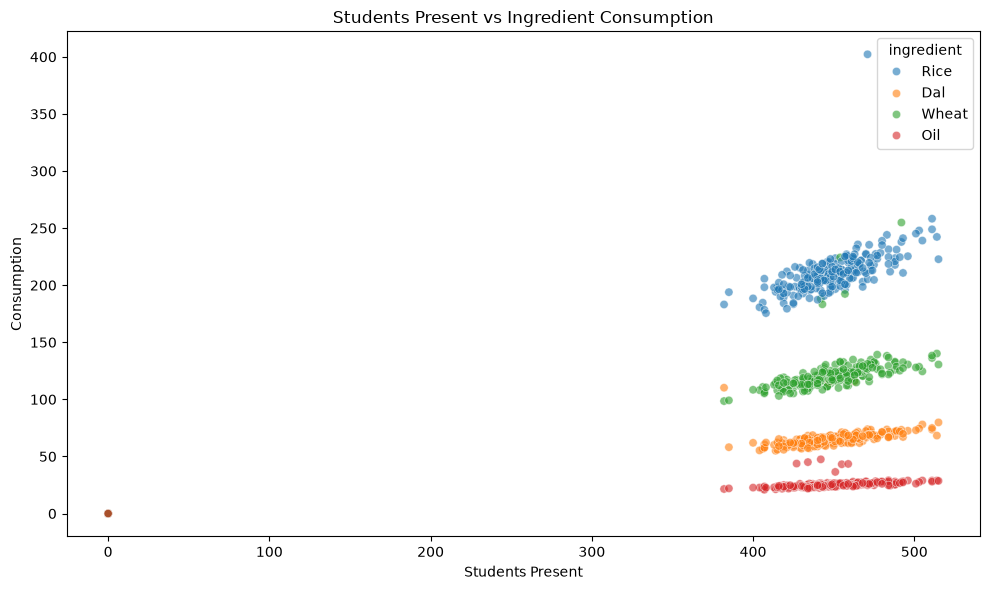

In [5]:
# Relationship between students present and consumption

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="students_present",
    y="consumption",
    hue="ingredient",
    alpha=0.6
)

plt.title("Students Present vs Ingredient Consumption")
plt.xlabel("Students Present")
plt.ylabel("Consumption")
plt.tight_layout()
plt.show()

In [7]:
## Feature engineering for demand forecasting

df = df.sort_values(["ingredient", "date"]).reset_index(drop=True)

# Previous day's consumption
df["previous_day_consumption"] = (
    df.groupby("ingredient")["consumption"]
    .shift(1)
)

# Previous 7-day average consumption
# shift(1) ensures today's consumption is NOT used
df["rolling_7_day_consumption"] = (
    df.groupby("ingredient")["consumption"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=7,
            min_periods=1
        ).mean()
    )
)

# Day of week
df["day_of_week_num"] = df["date"].dt.dayofweek

# Month
df["month_num"] = df["date"].dt.month

# Target = next day's consumption
df["target_consumption"] = (
    df.groupby("ingredient")["consumption"]
    .shift(-1)
)

print(df[
    [
        "date",
        "ingredient",
        "students_present",
        "meals_served",
        "consumption",
        "previous_day_consumption",
        "rolling_7_day_consumption",
        "day_of_week_num",
        "month_num",
        "target_consumption"
    ]
].head(15))

         date ingredient  students_present  meals_served  consumption  \
0  2025-04-01        Dal               462           462        62.22   
1  2025-04-02        Dal               446           446        64.65   
2  2025-04-03        Dal               406           406        56.66   
3  2025-04-04        Dal               435           435        61.42   
4  2025-04-05        Dal                 0             0         0.00   
5  2025-04-06        Dal                 0             0         0.00   
6  2025-04-07        Dal               434           434        60.29   
7  2025-04-08        Dal               442           442        62.12   
8  2025-04-09        Dal               468           468        63.40   
9  2025-04-10        Dal               454           454        65.13   
10 2025-04-11        Dal               475           475        65.04   
11 2025-04-12        Dal                 0             0         0.00   
12 2025-04-13        Dal                 0         

In [8]:
# -----------------------------------------
# Demand Forecasting - Random Forest
# -----------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Remove rows where features or target are unavailable
model_df = df.dropna(
    subset=[
        "previous_day_consumption",
        "rolling_7_day_consumption",
        "target_consumption"
    ]
).copy()

# Features used by the model
features = [
    "ingredient",
    "students_present",
    "meals_served",
    "previous_day_consumption",
    "rolling_7_day_consumption",
    "day_of_week_num",
    "month_num",
    "holiday",
    "current_stock",
    "received_quantity"
]

target = "target_consumption"

X = model_df[features]
y = model_df[target]

# -----------------------------------------
# Chronological train/test split
# -----------------------------------------

split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# -----------------------------------------
# Encode ingredient
# -----------------------------------------

categorical_features = ["ingredient"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "ingredient_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# -----------------------------------------
# Train Random Forest
# -----------------------------------------

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_encoded, y_train)

# -----------------------------------------
# Make predictions
# -----------------------------------------

y_pred = model.predict(X_test_encoded)

# -----------------------------------------
# Evaluation
# -----------------------------------------

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-----------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Training samples: 1161
Testing samples: 291

Model Performance
-----------------------------
MAE  : 11.86
RMSE : 23.12
R²   : 0.8516


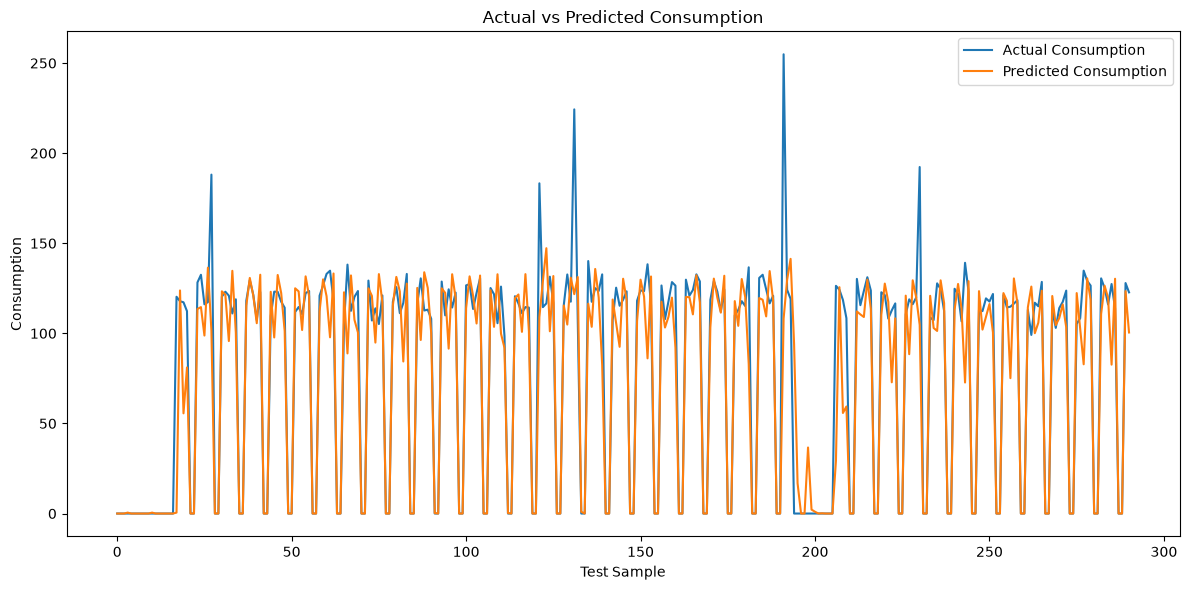

In [9]:
# -----------------------------------------
# Actual vs Predicted Consumption
# -----------------------------------------

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

plt.figure(figsize=(12, 6))

plt.plot(
    results["Actual"].values,
    label="Actual Consumption"
)

plt.plot(
    results["Predicted"].values,
    label="Predicted Consumption"
)

plt.title("Actual vs Predicted Consumption")
plt.xlabel("Test Sample")
plt.ylabel("Consumption")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# -----------------------------------------
# Save the trained forecasting model
# -----------------------------------------

import os
import joblib

# Make sure the models directory exists
os.makedirs("../models", exist_ok=True)

# Save model + preprocessing together
model_package = {
    "model": model,
    "preprocessor": preprocessor,
    "features": features
}

model_path = "../models/demand_forecasting_model.joblib"

joblib.dump(
    model_package,
    model_path
)

print("Model saved successfully!")
print(f"Location: {model_path}")

Model saved successfully!
Location: ../models/demand_forecasting_model.joblib


In [11]:
# -----------------------------------------
# Anomaly Detection - Isolation Forest
# -----------------------------------------

from sklearn.ensemble import IsolationForest

# Work on consumption-related features
anomaly_data = df[
    [
        "ingredient",
        "students_present",
        "meals_served",
        "consumption",
        "previous_day_consumption",
        "rolling_7_day_consumption"
    ]
].copy()

# Remove rows with missing values
anomaly_data = anomaly_data.dropna().reset_index(drop=True)

# Encode ingredient
anomaly_encoded = pd.get_dummies(
    anomaly_data,
    columns=["ingredient"],
    dtype=int
)

# Create Isolation Forest model
anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

# Train and predict
anomaly_predictions = anomaly_model.fit_predict(
    anomaly_encoded
)

# Isolation Forest:
#  1  = normal
# -1  = anomaly

anomaly_data["anomaly_prediction"] = anomaly_predictions

anomaly_data["anomaly"] = anomaly_data[
    "anomaly_prediction"
].map({
    1: "Normal",
    -1: "Anomaly"
})

# Anomaly score
anomaly_data["anomaly_score"] = (
    anomaly_model.decision_function(anomaly_encoded)
)

# Display summary
print("Anomaly Detection Results")
print("-----------------------------")

print(
    anomaly_data["anomaly"].value_counts()
)

print("\nDetected anomalies:")

print(
    anomaly_data[
        anomaly_data["anomaly"] == "Anomaly"
    ][
        [
            "students_present",
            "meals_served",
            "consumption",
            "previous_day_consumption",
            "rolling_7_day_consumption",
            "anomaly_score"
        ]
    ].head(20)
)

Anomaly Detection Results
-----------------------------
anomaly
Normal     1426
Anomaly      30
Name: count, dtype: int64

Detected anomalies:
      students_present  meals_served  consumption  previous_day_consumption  \
184                382           382       110.20                     71.82   
185                  0             0         0.00                    110.20   
355                515           515        79.81                      0.00   
465                  0             0         0.00                     47.47   
729                406           406       184.68                    207.47   
731                  0             0         0.00                    195.58   
818                457           457       195.84                      0.00   
822                  0             0         0.00                    198.42   
892                  0             0         0.00                    180.67   
913                  0             0         0.00                  

In [12]:
# -----------------------------------------
# Save Anomaly Detection Model
# -----------------------------------------

import os
import joblib

# Make sure models directory exists
os.makedirs("../models", exist_ok=True)

anomaly_model_path = "../models/anomaly_detection_model.joblib"

joblib.dump(
    anomaly_model,
    anomaly_model_path
)

print("Anomaly detection model saved successfully!")
print(f"Location: {anomaly_model_path}")

Anomaly detection model saved successfully!
Location: ../models/anomaly_detection_model.joblib


In [14]:
# -----------------------------------------
# Stockout Prediction
# -----------------------------------------

# Get the latest inventory record for each ingredient
latest_inventory = (
    df.sort_values("date")
    .groupby("ingredient")
    .tail(1)
    .copy()
)

# Calculate average consumption over the latest 7 records
recent_demand = (
    df.sort_values("date")
    .groupby("ingredient")
    .tail(7)
    .groupby("ingredient")["consumption"]
    .mean()
    .rename("expected_daily_demand")
)

# Attach demand to latest inventory
latest_inventory = latest_inventory.merge(
    recent_demand,
    on="ingredient",
    how="left"
)

# Calculate estimated days of stock remaining
latest_inventory["estimated_days_remaining"] = np.where(
    latest_inventory["expected_daily_demand"] > 0,
    latest_inventory["current_stock"]
    / latest_inventory["expected_daily_demand"],
    np.inf
)


# -----------------------------------------
# Stockout warning level
# -----------------------------------------

def stockout_status(days):
    if days <= 1:
        return "Critical"
    elif days <= 3:
        return "Warning"
    else:
        return "Normal"


latest_inventory["stockout_status"] = (
    latest_inventory["estimated_days_remaining"]
    .apply(stockout_status)
)


# -----------------------------------------
# Display results
# -----------------------------------------

print("Stockout Prediction")
print("-----------------------------")

print(
    latest_inventory[
        [
            "ingredient",
            "current_stock",
            "expected_daily_demand",
            "estimated_days_remaining",
            "stockout_status"
        ]
    ].to_string(index=False)
)

Stockout Prediction
-----------------------------
ingredient  current_stock  expected_daily_demand  estimated_days_remaining stockout_status
       Oil          27.80              18.608571                  1.493935         Warning
       Dal         128.54              49.527143                  2.595345         Warning
      Rice         119.65             162.461429                  0.736483        Critical
     Wheat         350.00              86.848571                  4.030003          Normal


In [15]:
# -----------------------------------------
# Smart Reorder Recommendation
# -----------------------------------------

# Safety stock as a percentage of expected daily demand
SAFETY_STOCK_DAYS = 2

# Calculate safety stock
latest_inventory["safety_stock"] = (
    latest_inventory["expected_daily_demand"]
    * SAFETY_STOCK_DAYS
)

# Estimate requirement for the next 7 days
latest_inventory["seven_day_requirement"] = (
    latest_inventory["expected_daily_demand"] * 7
)

# Recommended purchase quantity
latest_inventory["recommended_purchase"] = (
    latest_inventory["seven_day_requirement"]
    + latest_inventory["safety_stock"]
    - latest_inventory["current_stock"]
)

# Do not recommend negative quantities
latest_inventory["recommended_purchase"] = (
    latest_inventory["recommended_purchase"]
    .clip(lower=0)
    .round(2)
)

# -----------------------------------------
# Display recommendations
# -----------------------------------------

print("Smart Reorder Recommendations")
print("-----------------------------")

print(
    latest_inventory[
        [
            "ingredient",
            "current_stock",
            "expected_daily_demand",
            "safety_stock",
            "seven_day_requirement",
            "recommended_purchase"
        ]
    ].to_string(index=False)
)

Smart Reorder Recommendations
-----------------------------
ingredient  current_stock  expected_daily_demand  safety_stock  seven_day_requirement  recommended_purchase
       Oil          27.80              18.608571     37.217143                 130.26                139.68
       Dal         128.54              49.527143     99.054286                 346.69                317.20
      Rice         119.65             162.461429    324.922857                1137.23               1342.50
     Wheat         350.00              86.848571    173.697143                 607.94                431.64


In [16]:
# -----------------------------------------
# Save Reorder Recommendations
# -----------------------------------------

reorder_output = latest_inventory[
    [
        "ingredient",
        "current_stock",
        "expected_daily_demand",
        "safety_stock",
        "seven_day_requirement",
        "recommended_purchase"
    ]
].copy()

reorder_output.to_csv(
    "../data/processed/reorder_recommendations.csv",
    index=False
)

print("Reorder recommendations saved successfully!")
print("Location: ../data/processed/reorder_recommendations.csv")

print("\nRecommendations:")
print(reorder_output.to_string(index=False))

Reorder recommendations saved successfully!
Location: ../data/processed/reorder_recommendations.csv

Recommendations:
ingredient  current_stock  expected_daily_demand  safety_stock  seven_day_requirement  recommended_purchase
       Oil          27.80              18.608571     37.217143                 130.26                139.68
       Dal         128.54              49.527143     99.054286                 346.69                317.20
      Rice         119.65             162.461429    324.922857                1137.23               1342.50
     Wheat         350.00              86.848571    173.697143                 607.94                431.64
